In [ ]:
!pip install split-folders
!pip install torch-summary

In [ ]:
!pip install kaggle

In [ ]:
import os
import json
from zipfile import ZipFile
from PIL import Image

In [ ]:
kaggle_credentails = json.load(open("/content/kaggle.json"))

In [ ]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [ ]:
!kaggle datasets download -d preetviradiya/brian-tumor-dataset

Dataset URL: https://www.kaggle.com/datasets/preetviradiya/brian-tumor-dataset
License(s): GPL-2.0
  0% 0.00/107M [00:00<?, ?B/s]
100% 107M/107M [00:00<00:00, 1.75GB/s]


In [ ]:
!ls

brain_tumor.jpg  brian-tumor-dataset.zip  kaggle.json  sample_data


In [ ]:
# Unzip the downloaded dataset
with ZipFile("brian-tumor-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style='darkgrid')
import copy #  functions for creating copies of objects, useful for avoiding unintended modifications to variables.
import os #  interact with the operating system, for  file and directory manipulation.
import torch
from PIL import Image # Imaging Library (PIL)  for opening, manipulating, and saving various image file formats.
from torch.utils.data import Dataset #  represents a dataset and provides an interface for accessing and processing the data during training.
import torchvision
import torchvision.transforms as transforms #  provides common image transformations, such as resizing, cropping, and normalization.
from torch.utils.data import random_split #  for randomly splitting a dataset into training and validation subsets.
from torch.optim.lr_scheduler import ReduceLROnPlateau # scheduler adjusts the learning rate during training based on a specified metric.
import torch.nn as nn #  provides classes for defining and building neural networks.
from torchvision import utils #  torchvision module that contains utility functions for working with images, such as saving and visualizing them.
from torchvision.datasets import ImageFolder
import splitfolders
from torchsummary import summary
import torch.nn.functional as F
import pathlib
from sklearn.metrics import confusion_matrix, classification_report
import itertools #  provides functions for efficient looping and combining of iterables, for tasks such as generating combinations or permutations of elements.
from tqdm.notebook import trange, tqdm # These functions allow for the creation of progress bars to track the progress of loops or tasks.
from torch import optim
import warnings
warnings.filterwarnings('ignore')

In [ ]:
labels_df = pd.read_csv('/content/metadata.csv')
print(labels_df.head().to_markdown())

|    |   Unnamed: 0 | image           | class   | format   | mode   | shape         |
|---:|-------------:|:----------------|:--------|:---------|:-------|:--------------|
|  0 |            0 | Cancer (1).jpg  | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  1 |            1 | Cancer (1).png  | tumor   | PNG      | L      | (300, 240)    |
|  2 |            2 | Cancer (1).tif  | tumor   | TIFF     | RGB    | (256, 256, 3) |
|  3 |            3 | Cancer (10).jpg | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  4 |            4 | Cancer (10).tif | tumor   | TIFF     | RGB    | (256, 256, 3) |


In [ ]:
os.listdir('/content/Brain Tumor Data Set')

['Brain Tumor Data Set']

In [ ]:
labels_df.shape

(4600, 6)

In [ ]:
# Dataset Path
data_dir = '/content/Brain Tumor Data Set/Brain Tumor Data Set'
data_dir = pathlib.Path(data_dir)

# Splitting dataset to train_set, val_set and test_set
splitfolders.ratio(data_dir, output='/content/brain', seed=20, ratio=(0.8, 0.2))


# New dataset path
data_dir = '/content/brain'
data_dir = pathlib.Path(data_dir)

Copying files: 4600 files [00:01, 3321.44 files/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define transformation
transform = transforms.Compose(
    [
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])
   ]
)

In [ ]:
# Define an object of the custom dataset for the train and validation.
train_set = torchvision.datasets.ImageFolder("/content/brain/train", transform=transform)
train_set.transform
val_set = torchvision.datasets.ImageFolder("/content/brain/val", transform=transform)
val_set.transform

Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [ ]:
import shutil
import os
import pandas as pd

# Define the base directories
train_base_dir = '/content/brain/train'
val_base_dir = '/content/brain/val'

# Define class names based on your dataset
class_names = ['Brain Tumor', 'Healthy'] # Assuming these are your class names

# Create class directories within train and val if they don't exist
for class_name in class_names:
    os.makedirs(os.path.join(train_base_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_base_dir, class_name), exist_ok=True)

# Get the original data directory name from the splitfolders input
original_data_dir_name = os.path.basename('/content/Brain Tumor Data Set/Brain Tumor Data Set')


# Assuming splitfolders created a structure like /content/brain/train/original_data_dir_name/class_name/image.jpg
# We need to move images from these nested class folders to the class folders directly under train and val.

source_train_nested_base = os.path.join(train_base_dir, original_data_dir_name)
source_val_nested_base = os.path.join(val_base_dir, original_data_dir_name)


# Move files from the nested class folders to the target class folders
for class_name in class_names:
    source_train_class_dir = os.path.join(source_train_nested_base, class_name)
    destination_train_class_dir = os.path.join(train_base_dir, class_name)

    if os.path.exists(source_train_class_dir):
        for item_file in os.listdir(source_train_class_dir):
            shutil.move(os.path.join(source_train_class_dir, item_file), destination_train_class_dir)
        # Remove the empty nested class directory
        os.rmdir(source_train_class_dir)

    source_val_class_dir = os.path.join(source_val_nested_base, class_name)
    destination_val_class_dir = os.path.join(val_base_dir, class_name)

    if os.path.exists(source_val_class_dir):
        for item_file in os.listdir(source_val_class_dir):
            shutil.move(os.path.join(source_val_class_dir, item_file), destination_val_class_dir)
        # Remove the empty nested class directory
        os.rmdir(source_val_class_dir)

# Attempt to remove the empty intermediate nested directory if it exists
if os.path.exists(source_train_nested_base) and not os.listdir(source_train_nested_base):
    os.rmdir(source_train_nested_base)

if os.path.exists(source_val_nested_base) and not os.listdir(source_val_nested_base):
    os.rmdir(source_val_nested_base)


print("Directory structure correction complete.")

Directory structure correction complete.


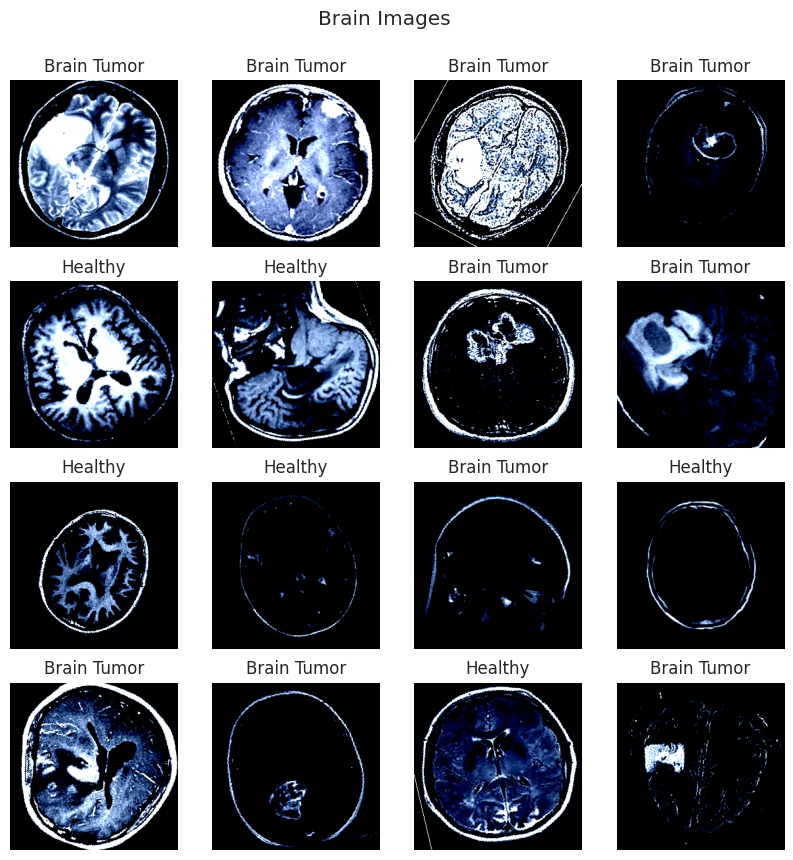

In [ ]:
# Visualiztion some images from Train Set
CLA_label = {
    0 : 'Brain Tumor',
    1 : 'Healthy'
}







figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(CLA_label[label])
    plt.axis("off")
    img_np = img.numpy().transpose((1, 2, 0))
    # Clip pixel values to [0, 1]
    img_valid_range = np.clip(img_np, 0, 1)
    plt.imshow(img_valid_range)
    plt.suptitle('Brain Images', y=0.95)
plt.show()

In [ ]:
# import and load train, validation
batch_size = 64

train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle = True, num_workers = 2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle = True, num_workers = 2)

In [ ]:
# print shape for Training data and Validation data
for key, value in {'Training data': train_loader, "Validation data": val_loader}.items():
    for X, y in value:
        print(f"{key}:")
        print(f"Shape of X : {X.shape}")
        print(f"Shape of y: {y.shape} {y.dtype}\n")
        break

Training data:
Shape of X : torch.Size([64, 3, 256, 256])
Shape of y: torch.Size([64]) torch.int64

Validation data:
Shape of X : torch.Size([64, 3, 256, 256])
Shape of y: torch.Size([64]) torch.int64



In [ ]:
'''This function can be useful in determining the output size of a convolutional layer in a neural network,
given the input dimensions and the convolutional layer's parameters.'''

def findConv2dOutShape(hin,win,conv,pool=2):
    # get conv arguments
    kernel_size = conv.kernel_size
    stride=conv.stride
    padding=conv.padding
    dilation=conv.dilation

    hout=np.floor((hin+2*padding[0]-dilation[0]*(kernel_size[0]-1)-1)/stride[0]+1)
    wout=np.floor((win+2*padding[1]-dilation[1]*(kernel_size[1]-1)-1)/stride[1]+1)

    if pool:
        hout/=pool
        wout/=pool
    return int(hout),int(wout)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_LSTM_TUMOR(nn.Module):
    def __init__(self, params):
        super(CNN_LSTM_TUMOR, self).__init__()

        Cin, Hin, Win = params["shape_in"]
        num_fc1 = params["num_fc1"]       # LSTM hidden size
        num_fc2 = params["num_fc2"]
        num_classes = params["num_classes"]
        self.dropout_rate = params["dropout_rate"]

        # --------------------
        # CNN FEATURE EXTRACTOR
        # --------------------
        self.conv1 = nn.Conv2d(Cin, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)   # Downsample by /2

        # After 2 poolings: 256 → 128 → 64
        H2, W2 = Hin // 4, Win // 4
        self.feature_size = 64 * W2      # per time step (row)


        # LSTM LAYER
        
        self.lstm = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=num_fc1,
            batch_first=True
        )

        # --------------------
        # FC LAYERS
        # --------------------
        self.fc2 = nn.Linear(num_fc1, num_fc2)
        self.fc3 = nn.Linear(num_fc2, num_classes)

    def forward(self, X):
        # CNN feature extraction
        X = F.relu(self.conv1(X))
        X = self.pool(F.relu(self.conv2(X)))  # (batch, 64, 128, 128)
        X = self.pool(X)                      # (batch, 64, 64, 64)

        # Reshape for LSTM (treat rows as sequence)
        # → (batch, seq_len=64, features=64*64)
        X = X.permute(0, 2, 1, 3)   # (batch, H, C, W)
        X = X.reshape(X.size(0), X.size(1), -1)

        # LSTM forward
        lstm_out, _ = self.lstm(X)

        # Last time step
        X = lstm_out[:, -1, :]

        # FC layers
        X = F.relu(self.fc2(X))
        X = F.dropout(X, p=self.dropout_rate)
        X = self.fc3(X)

        return F.log_softmax(X, dim=1)


In [ ]:
params_model={
        "shape_in": (3,256,256),
        "initial_filters": 8,
        "num_fc1": 100,
        "num_fc2": 50,

        "dropout_rate": 0.25,
        "num_classes": 2}

# Create instantiation of Network class
cnn_lstm_model = CNN_LSTM_TUMOR(params_model)

# define computation hardware approach (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = cnn_lstm_model
model.to(device)

CNN_LSTM_TUMOR(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(4096, 100, batch_first=True)
  (fc2): Linear(in_features=100, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=2, bias=True)
)

In [ ]:
#Model Summary for CNN Model
summary(cnn_lstm_model, input_size=(3, 256, 256),device=device.type)

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            896
├─Conv2d: 1-2                            18,496
├─MaxPool2d: 1-3                         --
├─LSTM: 1-4                              1,679,200
├─Linear: 1-5                            5,050
├─Linear: 1-6                            102
Total params: 1,703,744
Trainable params: 1,703,744
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            896
├─Conv2d: 1-2                            18,496
├─MaxPool2d: 1-3                         --
├─LSTM: 1-4                              1,679,200
├─Linear: 1-5                            5,050
├─Linear: 1-6                            102
Total params: 1,703,744
Trainable params: 1,703,744
Non-trainable params: 0

In [ ]:
loss_func = nn.NLLLoss(reduction="sum")

In [ ]:
opt = optim.Adam(cnn_lstm_model.parameters(), lr=3e-4)
lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=20)

In [ ]:
# Function to get the learning rate
def get_lr(opt):
    for param_group in opt.param_groups:
        return param_group['lr']

# Function to compute the loss value per batch of data
def loss_batch(loss_func, output, target, opt=None):

    loss = loss_func(output, target) # get loss
    pred = output.argmax(dim=1, keepdim=True) # Get Output Class
    metric_b=pred.eq(target.view_as(pred)).sum().item() # get performance metric

    if opt is not None:
        opt.zero_grad()
        loss.backward()
        opt.step()

    return loss.item(), metric_b

# Compute the loss value & performance metric for the entire dataset (epoch)
def loss_epoch(model,loss_func,dataset_dl,opt=None):

    run_loss=0.0
    t_metric=0.0
    len_data=len(dataset_dl.dataset)

    # internal loop over dataset
    for xb, yb in dataset_dl:
        # move batch to device
        xb=xb.to(device)
        yb=yb.to(device)
        output=model(xb) # get model output
        loss_b,metric_b=loss_batch(loss_func, output, yb, opt) # get loss per batch
        run_loss+=loss_b        # update running loss

        if metric_b is not None: # update running metric
            t_metric+=metric_b

    loss=run_loss/float(len_data)  # average loss value
    metric=t_metric/float(len_data) # average metric value

    return loss, metric

In [ ]:
def Train_Val(model, params,verbose=False):

    # Get the parameters
    epochs=params["epochs"]
    loss_func=params["f_loss"]
    opt=params["optimiser"]
    train_dl=params["train"]
    val_dl=params["val"]
    lr_scheduler=params["lr_change"]
    weight_path=params["weight_path"]

    # history of loss values in each epoch
    loss_history={"train": [],"val": []}
    # histroy of metric values in each epoch
    metric_history={"train": [],"val": []}
    # a deep copy of weights for the best performing model
    best_model_wts = copy.deepcopy(model.state_dict())
    # initialize best loss to a large value
    best_loss=float('inf')

# Train Model n_epochs (the progress of training by printing the epoch number and the associated learning rate. It can be helpful for debugging, monitoring the learning rate schedule, or gaining insights into the training process.)

    for epoch in tqdm(range(epochs)):

        # Get the Learning Rate
        current_lr=get_lr(opt)
        if(verbose):
            print('Epoch {}/{}, current lr={}'.format(epoch, epochs - 1, current_lr))


# Train Model Process


        model.train()
        train_loss, train_metric = loss_epoch(model,loss_func,train_dl,opt)

        # collect losses
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)


# Evaluate Model Process


        model.eval()
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model,loss_func,val_dl)

        # store best model
        if(val_loss < best_loss):
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

            # store weights into a local file
            torch.save(model.state_dict(), weight_path)
            if(verbose):
                print("Copied best model weights!")

        # collect loss and metric for validation dataset
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)

        # learning rate schedule
        lr_scheduler.step(val_loss)
        if current_lr != get_lr(opt):
            if(verbose):
                print("Loading best model weights!")
            model.load_state_dict(best_model_wts)

        if(verbose):
            print(f"train loss: {train_loss:.6f}, dev loss: {val_loss:.6f}, accuracy: {100*val_metric:.2f}")
            print("-"*10)

    # load best model weights
    model.load_state_dict(best_model_wts)

    return model, loss_history, metric_history

In [30]:
# Define various parameters used for training and evaluation of a cnn_model

params_train={
 "train": train_loader,"val": val_loader,
 "epochs": 100,
 "optimiser": optim.Adam(cnn_lstm_model.parameters(),lr=0.0003),
 "lr_change": ReduceLROnPlateau(opt,
                                mode='min',
                                factor=0.5,
                                patience=20), # Removed verbose=0
 "f_loss": nn.NLLLoss(reduction="sum"),
 "weight_path": "weights.pt",
}

# train and validate the model
ann_model,loss_hist,metric_hist = Train_Val(cnn_lstm_model,params_train)

  0%|          | 0/100 [00:00<?, ?it/s]

In [31]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"\nModel Accuracy on Test Data: {accuracy:.2f}%")
    return accuracy


In [32]:
accuracy = evaluate_model(cnn_lstm_model, val_loader, device)


Model Accuracy on Test Data: 98.59%


<Axes: >

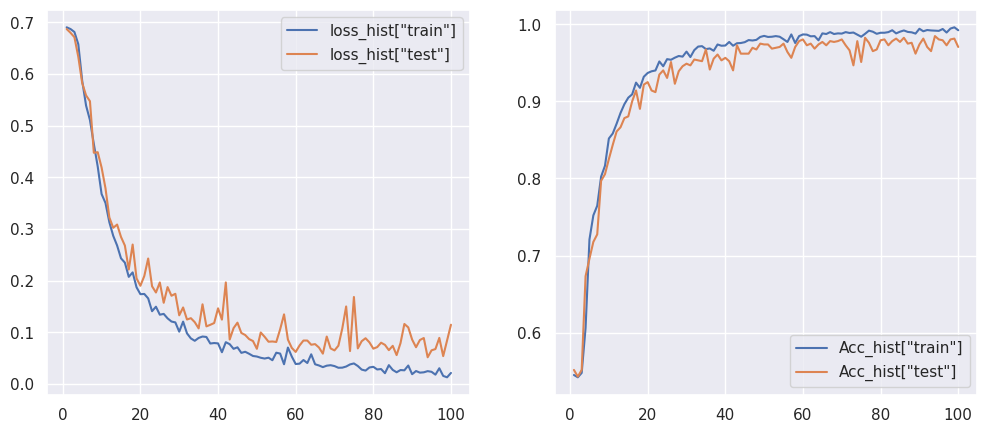

In [33]:
epochs=params_train["epochs"]
fig,ax = plt.subplots(1,2,figsize=(12,5))

sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["train"],ax=ax[0],label='loss_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["val"],ax=ax[0],label='loss_hist["test"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["train"],ax=ax[1],label='Acc_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["val"],ax=ax[1],label='Acc_hist["test"]')

In [34]:
# define function For Classification Report
def Ture_and_Pred(val_loader, model):
    i = 0
    y_true = []
    y_pred = []
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.numpy()
        outputs = model(images)
        _, pred = torch.max(outputs.data, 1)
        pred = pred.detach().cpu().numpy()

        y_true = np.append(y_true, labels)
        y_pred = np.append(y_pred, pred)

    return y_true, y_pred


# check confusion matrix for error analysis
y_true, y_pred = Ture_and_Pred(val_loader, cnn_lstm_model)

print(classification_report(y_true, y_pred), '\n\n')
cm = confusion_matrix(y_true, y_pred)

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       503
         1.0       0.97      0.98      0.98       418

    accuracy                           0.98       921
   macro avg       0.98      0.98      0.98       921
weighted avg       0.98      0.98      0.98       921
 




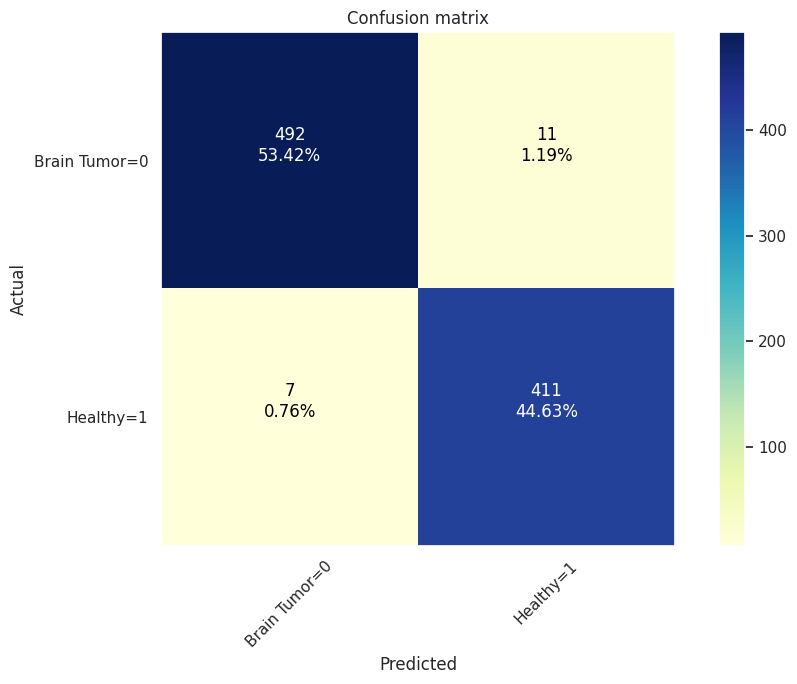

In [35]:
# Confusion Matrix Plotting Function
def show_confusion_matrix(cm, CLA_label, title='Confusion matrix', cmap=plt.cm.YlGnBu):

    plt.figure(figsize=(10,7))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(CLA_label))

    plt.xticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()], rotation=45)
    plt.yticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()])

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i,j]}\n{cm[i,j]/np.sum(cm)*100:.2f}%", horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

show_confusion_matrix(cm, CLA_label)

In [36]:
torch.save(cnn_lstm_model, "CNN_LSTMBrain_Tumor_model.pt")

In [37]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

# Define the class labels (based on ImageFolder class index)
CLA_label = {
    0: 'Brain Tumor',
    1: 'Healthy'
}

# Define the image preprocessing (same as during training)
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def detect_and_display(img_path, model, device, class_labels=CLA_label):
    """
    Loads an image, preprocesses it, makes prediction using the trained model,
    and displays the image with the predicted label and confidence.
    """
    try:
        # Load and preprocess image
        img = Image.open(img_path).convert('RGB')
        img_tensor = test_transform(img).unsqueeze(0).to(device)  # Add batch dim

        # Put model in evaluation mode
        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
            probs = F.softmax(outputs, dim=1)
            confidence, predicted_class = torch.max(probs, 1)
            predicted_class = predicted_class.item()
            confidence = confidence.item()

        # Display prediction
        label = class_labels[predicted_class]
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{label} (Confidence: {confidence * 100:.2f}%)", fontsize=14)
        plt.show()

    except Exception as e:
        print("Error:", e)


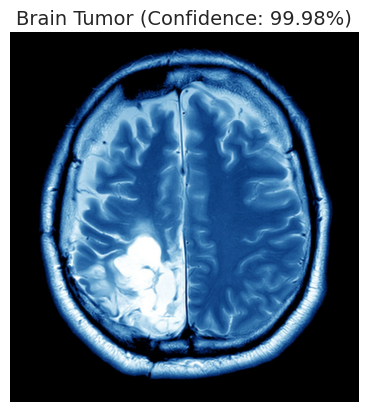

In [38]:
image_path = '/content/brain_tumor.jpg'
detect_and_display(image_path, cnn_lstm_model, device)
